[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ofermend/hands-on-rag/blob/main/chapter2/parse-docx.ipynb)

# Chapter 2: Parsing DOCX Documents

In RAG pipelines, data comes in many formats — and Microsoft Word documents are among the most common in enterprise environments. Unlike plain text, DOCX files contain structured elements like paragraphs, tables, and embedded images that require specialized extraction.

This notebook demonstrates how to extract text, tables, and images from Word documents using python-docx.

**What you'll learn:**
- Extract paragraph text from DOCX files
- Parse table data into structured formats
- Extract embedded images from the DOCX archive

**Prerequisites:** `pip install python-docx Pillow`

## Setup and Text Extraction

We open a sample DOCX file with python-docx and iterate over its paragraphs and tables to extract structured text content.

In [1]:
import os
from docx import Document
from IPython.display import display, Image

document = Document('sample_data/sample_data.docx')

# extract text 
for para in document.paragraphs:
  if len(para.text.strip()) > 0:  # Only print non-empty paragraphs
    print(para.text, end="\n---\n") 

# extract tables
for table in document.tables:
  print("\n--- Table ---")
  for row in table.rows:
    row_text = [cell.text for cell in row.cells]
    print(row_text)

Sample doc for RAG Book chapter 2
---
This is a great chapter 
---

--- Table ---
['Revision', 'Year']
['0.0.1', '2025']

--- Table ---
['Book', 'Revision', 'Year', 'Author']
['Memory and RAG', '0.1.0', '2026', 'A great researcher']
['RAG and AI', '0.0.1', '2025', 'A great researcher']


## Image Extraction

DOCX files are ZIP archives internally, so we can open them with `zipfile` and pull out embedded image files by their extension.

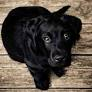

In [2]:
import zipfile

zipf = zipfile.ZipFile('sample_data/sample_data.docx')
filelist = zipf.namelist()
# print (filelist)

for fname in filelist:
  _, ext = os.path.splitext(fname)
  if ext in ['.jpg', '.jpeg', '.png', '.gif']:
    # read image and display in Jupyter
    with zipf.open(fname) as img_file:
        img_data = img_file.read()
        display(Image(data=img_data))